In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 22, 
                    "font.family" : "serif"})

# Adjacency Matrices

In [2]:
#Reading the matrices data

RawMatrix = []
label_check, matrix = True, []
with open("C://Users//Devashish//Dropbox//PC//Downloads//Data&ImportScript//dessin_data_matrix.txt",'r') as file:
    for line in file.readlines():
        if line == '\n':                                   #...if encounter empty row
            if not label_check:                            #...st just finished reading a matrix
                RawMatrix.append([np.array(matrix),label]) #...append matrix & label to Data
                matrix = []                                #...reinitialiase matrix
            label_check = not label_check                  #...change next input: label <--> matrix
        elif label_check:                                  #...update label
            label = int(line)
        elif not label_check:                              #...update matrix
            matrix.append([int(i) for i in list(line)[:-1]])
    RawMatrix.append([np.array(matrix),label])             #...append final matrix & label
print('Matrix (raw) data size:',len(RawMatrix))
del(file,label,label_check,line,matrix)

Matrix = [] #RawMatrix
for dessin1_idx in range(len(RawMatrix)):
    addcheck = True
    for dessin2_idx in range(len(Matrix)):
        if np.array_equal(RawMatrix[dessin1_idx][0],Matrix[dessin2_idx][0]): # and RawData[dessin1][1] == Data[dessincheck][1]: #add this if want to keep isomorphic dessins with same vertex labeling but different orbit label
            addcheck = False
            break
    if addcheck:
        Matrix.append(RawMatrix[dessin1_idx])
print('Matrix data size:',len(Matrix),'(with repeats removed)')
del(dessin1_idx,dessin2_idx,addcheck)

counts_matrix = np.zeros(4)
for dessin in Matrix:
    counts_matrix[dessin[1]-1] += 1
print('Class counts:',counts_matrix)
weights_matrix = [np.floor(x) for x in len(Matrix)/counts_matrix]
del(dessin)

Matrix (raw) data size: 191
Matrix data size: 184 (with repeats removed)
Class counts: [73. 63. 44.  4.]


In [3]:
#Printing the matrices

Matrix

[[array([[2, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 1, 0, 1, 0, 0, 0],
         [0, 1, 2, 0, 0, 0, 0, 0],
         [0, 0, 0, 2, 1, 0, 0, 0],
         [0, 1, 0, 1, 0, 0, 1, 0],
         [0, 0, 0, 0, 0, 2, 1, 0],
         [0, 0, 0, 0, 1, 1, 0, 1],
         [0, 0, 0, 0, 0, 0, 1, 2]]),
  1],
 [array([[2, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 1, 1, 0, 0, 0, 0],
         [0, 1, 2, 0, 0, 0, 0, 0],
         [0, 1, 0, 0, 2, 0, 0, 0],
         [0, 0, 0, 2, 0, 0, 1, 0],
         [0, 0, 0, 0, 0, 2, 1, 0],
         [0, 0, 0, 0, 1, 1, 0, 1],
         [0, 0, 0, 0, 0, 0, 1, 2]]),
  1],
 [array([[2, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 1, 0, 1, 0, 0, 0],
         [0, 1, 2, 0, 0, 0, 0, 0],
         [0, 0, 0, 2, 1, 0, 0, 0],
         [0, 1, 0, 1, 0, 1, 0, 0],
         [0, 0, 0, 0, 1, 0, 2, 0],
         [0, 0, 0, 0, 0, 2, 0, 1],
         [0, 0, 0, 0, 0, 0, 1, 2]]),
  2],
 [array([[2, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 1, 1, 0, 0, 0, 0],
         [0, 1, 2, 0, 0, 0, 0, 0],
         [0, 1, 0, 0, 1, 1, 0, 

In [4]:
#Galois orbit for each dessin

galois = []   #simple
for i in range(len(Matrix)):
    galo = Matrix[i][1]
    galois.append(galo)
    
galois;

In [2]:
import scipy
import sklearn
from sklearn.decomposition import PCA

In [6]:
#flattening the matrices other than there Galois orbit size 

a = []

for mat in Matrix:
    b = mat[0]
    a.append(b)

a = np.array(a)

flat_matrices = []

for matrix in a:
    mat = matrix.flatten()
    flat_matrices.append(mat)

In [7]:
flat_matrices

[array([2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2]),
 array([2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2]),
 array([2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2]),
 array([2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2]),
 array([2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1

In [8]:
flat_matrices = np.array(flat_matrices)
trans_flat = flat_matrices.T

In [9]:
data = flat_matrices

In [18]:
#Let's do the same thing using python inbuilt function of PCA, and check whether the resultsholds true or not.

matrix_dataset = data

num_components = 30
pca = PCA(n_components=num_components)

reduced_matrix = pca.fit_transform(matrix_dataset)

explained_variance_ratio = pca.explained_variance_ratio_
projected_datas = pca.transform(matrix_dataset)

print("Explained Variance Ratios:", explained_variance_ratio)
print("Total Explained Variance:", np.sum(explained_variance_ratio))

Explained Variance Ratios: [0.13612623 0.12399608 0.08536346 0.07338399 0.06725846 0.06279765
 0.0545955  0.04799219 0.04446762 0.0418898  0.03733439 0.03233048
 0.02927119 0.02680979 0.02458191 0.02225421 0.02013359 0.0141209
 0.01227115 0.01007304 0.00777795 0.00657371 0.00511734 0.00450884
 0.00297428 0.00275274 0.00122438 0.00064846 0.00045258 0.00043995]
Total Explained Variance: 0.9995218780149205


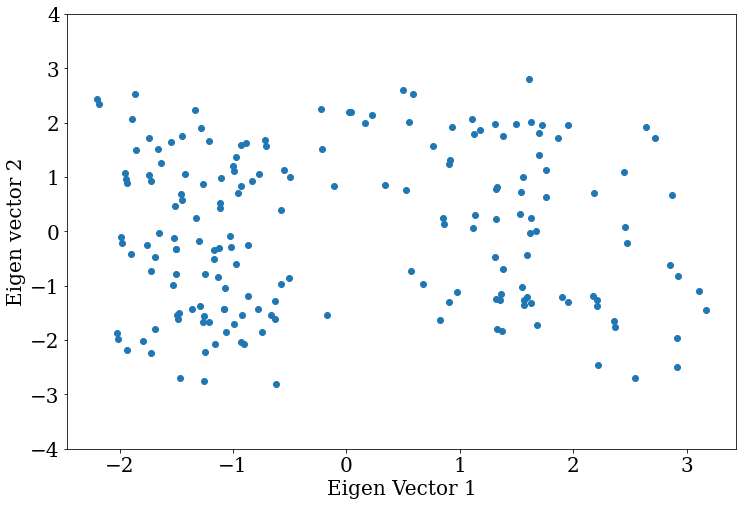

In [11]:
plt.figure(figsize = (12, 8))
plt.scatter(reduced_matrix[:, 0], reduced_matrix[:, 1])
plt.xticks(fontsize = "20")
plt.yticks(fontsize = "20")
plt.xlabel('Eigen Vector 1', fontsize = "20")
plt.ylabel('Eigen vector 2', fontsize = "20")
plt.savefig("2D_Projection_matrix_adjacency.pdf", format = 'pdf')
plt.ylim(-4, 4)
plt.show()

(array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.]),
 [Text(0, -4.0, '−4'),
  Text(0, -3.0, '−3'),
  Text(0, -2.0, '−2'),
  Text(0, -1.0, '−1'),
  Text(0, 0.0, '0'),
  Text(0, 1.0, '1'),
  Text(0, 2.0, '2'),
  Text(0, 3.0, '3'),
  Text(0, 4.0, '4')])

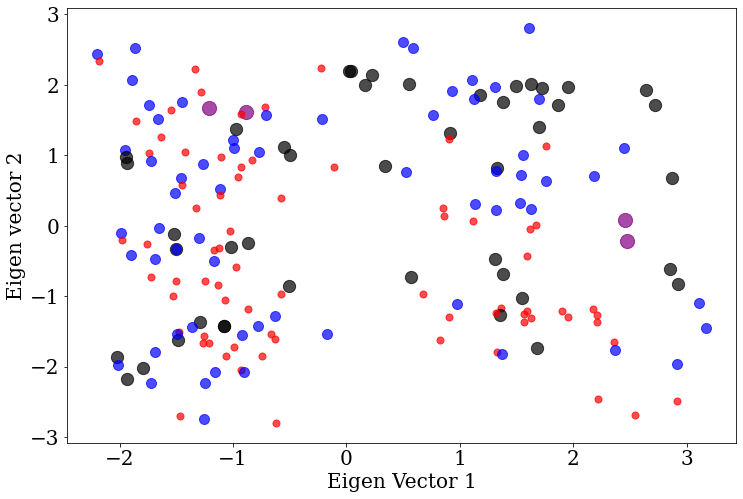

In [41]:
color_map = {1: 'red', 2: 'blue', 3: 'black', 4: 'purple'}

plt.figure(figsize=(12, 8))  # Set the size of the plot
sizes = np.array(galois)
x_values, y_values = reduced_matrix[:, 0], reduced_matrix[:, 1]

for size, x, y in zip(sizes, x_values, y_values):
    plt.scatter(x, y, s = size * 50, c=color_map[size], alpha=0.7)  # Adjust the size scaling factor (e.g., 100)
plt.savefig("galois_orbit_matrix_adjacency.pdf", format = 'pdf')
plt.xlabel('Eigen Vector 1', fontsize = "20")
plt.ylabel('Eigen vector 2', fontsize = "20")
plt.xticks(fontsize = "20")
plt.yticks(fontsize = "20")
#plt.title(f"{np.sum(explained_variance_ratio)}")
#plt.legend(fontsize = 20)

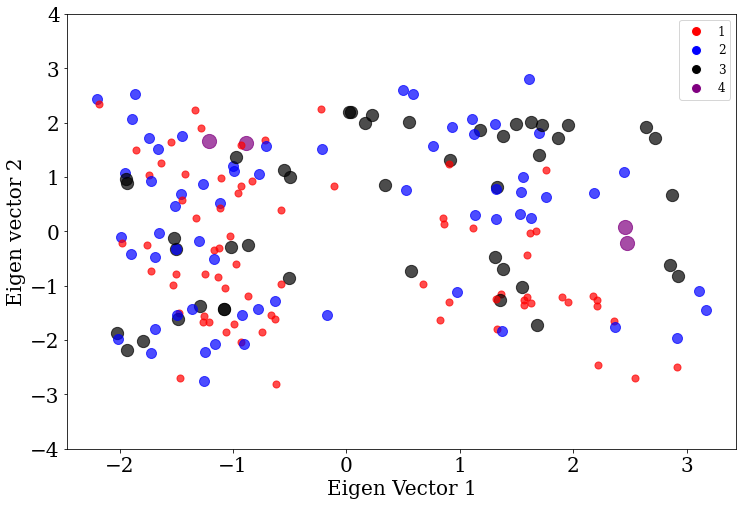

In [62]:
color_map = {1: 'red', 2: 'blue', 3: 'black', 4: 'purple'}

# Your code for creating the plot
plt.figure(figsize=(12, 8))
sizes = np.array(galois)
x_values, y_values = reduced_matrix[:, 0], reduced_matrix[:, 1]

for size, x, y in zip(sizes, x_values, y_values):
    plt.scatter(x, y, s=size * 50, c=color_map[size], alpha=0.7)

# Create a custom legend
legend_labels = {1: '1', 2: '2', 3: '3', 4: '4'}
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
                  for size, color, label in zip(color_map.keys(), color_map.values(), legend_labels.values())]
plt.legend(handles=legend_handles, fontsize=12)

plt.savefig("galois_orbit_matrix_adjacency.pdf", format='pdf')
plt.xlabel('Eigen Vector 1', fontsize=20)
plt.ylabel('Eigen vector 2', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(-4, 4)

plt.show()  # Display the plot

In [12]:
explained_variance_ratio = pca.explained_variance_ratio_
percentage_explained = explained_variance_ratio * 100

print("Explained Variance Ratios:", explained_variance_ratio)
print("Total Explained Variance:", np.sum(explained_variance_ratio))

Explained Variance Ratios: [0.13612623 0.12399608 0.08536346 0.07338399 0.06725846 0.06279765
 0.0545955  0.04799219 0.04446762 0.0418898  0.03733439 0.03233048
 0.02927119 0.02680979 0.02458191 0.02225421 0.02013359 0.0141209
 0.01227115 0.01007304]
Total Explained Variance: 0.9670516372676107


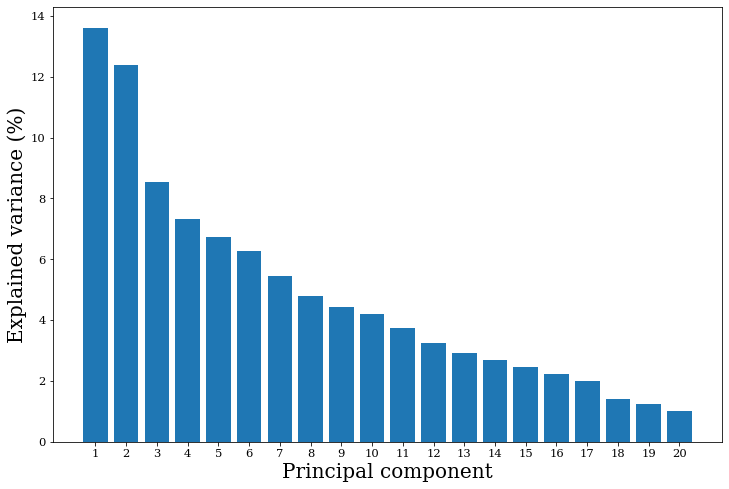

In [13]:
plt.figure(figsize = (12, 8))
plt.bar(range(1, num_components + 1), percentage_explained)
plt.xlabel('Principal component', fontsize = "20")
plt.ylabel('Explained variance (%)', fontsize = "20")
plt.yticks(fontsize = "11.5")
plt.xticks(fontsize = "11.5")
plt.xticks(range(1, num_components + 1))
plt.savefig("histogram_matrix_adjacency.pdf", format = 'pdf')
plt.show()

# K-Means Clustering

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Assuming you have projected your data into 10 dimensions (replace with your data)
projected_data = projected_datas  # Replace with your actual data

# Range of cluster numbers to try
cluster_range = range(1, 21)  # You can adjust this range as needed

In [33]:
# Initialize an empty list to store inertia values
inertia_values = []

# Iterate through the cluster range and fit K-Means for each number of clusters
for num_clusters in cluster_range:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(projected_data)
    inertia_values.append(kmeans.inertia_)

In [32]:
cluster_range, inertia_values

(range(1, 21),
 [3120.653972133812,
  2747.2053348926675,
  2542.05308699392,
  2407.3668422716432,
  2296.0976955946808,
  2193.6582937154294,
  2161.0050643570157,
  2100.963218857879,
  2020.5708627125139,
  1977.95650284473,
  1952.656657089416,
  1896.5320239867049,
  1817.9942772108445,
  1810.2415219855236,
  1768.3610523676443,
  1716.7778885035448,
  1709.3307376991138,
  1655.3273530929896,
  1628.2378997425117,
  1607.6100295406532])

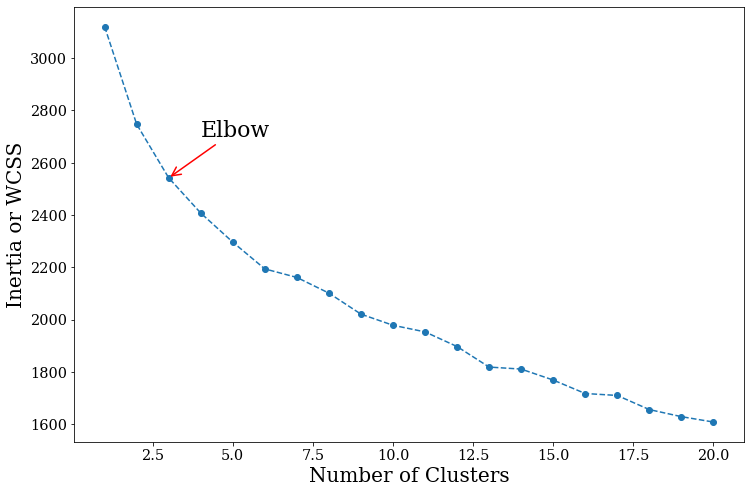

In [35]:
# Plot the inertia values against the number of clusters

plt.figure(figsize=(12, 8))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='--')
#plt.title('Elbow Method for Optimal Cluster Number')
plt.xlabel('Number of Clusters', fontsize = "20")
plt.ylabel('Inertia or WCSS', fontsize = "20")
plt.yticks(fontsize = "14.5")
plt.xticks(fontsize = "14.5")
plt.annotate('Elbow', xy=(3, 2542), xytext=(4, 2700),
             arrowprops=dict(arrowstyle='->', lw=1.5, color='r'))
plt.savefig("clustering_matrix_adjency.pdf")
plt.show()

# Cyclic

In [3]:
Cyclic = []
with open('C://Users//Devashish//Dropbox//PC//Downloads//Data&ImportScript//dessin_data_cyclic.txt','r') as file:
    for line in file.readlines():
        Cyclic.append(eval(line.replace('\n','').replace('{','[').replace('}',']').replace('(','[').replace(')',']')))
print('Cyclic data size:',len(Cyclic))
del(file,line)

counts_cyclic = np.zeros(4)
for dessin in Cyclic:
    counts_cyclic[dessin[2]-1] += 1
print('Class counts:',counts_cyclic)
weights_cyclic = [np.floor(x) for x in len(Cyclic)/counts_cyclic]
del(dessin)

Cyclic data size: 191
Class counts: [76. 66. 45.  4.]


In [4]:
import scipy
import sklearn
from sklearn.decomposition import PCA

In [5]:
Matrix_cyc = Cyclic
Matrix_cyc[0]

[[[1, 9, 5],
  [2, 3, 12],
  [10, 13, 15],
  [11, 17, 14],
  [18, 23, 22],
  [4, 8, 24],
  [16, 21, 20],
  [6, 19, 7]],
 [[1, 2],
  [3, 4],
  [5, 6],
  [7, 8],
  [9, 10],
  [11, 12],
  [13, 14],
  [15, 16],
  [17, 18],
  [19, 20],
  [21, 22],
  [23, 24]],
 1]

In [6]:
galois_cyc = []   #cyclic
for i in range(len(Matrix_cyc)):
    galo_cyc = Matrix_cyc[i][2]
    galois_cyc.append(galo_cyc)
    
galois_cyc

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 3,
 3,
 3,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 2,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 3,
 3,
 3,
 1,
 3,
 3,
 3,
 1,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 2,
 1,
 3,
 3,
 3,
 1,
 3,
 3,
 3,
 1,
 1,
 1,
 3,
 3,
 3,
 2,
 2,
 1,
 1,
 1,
 1,
 3,
 3,
 3,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 3,
 3,
 3,
 1,
 3,
 3,
 3,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 1,
 3,
 3,
 3,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 4,
 4,
 4,
 4,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 3,
 3,
 3,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 2,
 2,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 1]

In [7]:
a = []

for mat in Matrix_cyc:
    b = mat[0]
    a.append(b)

a = np.array(a)

flat_matrices_cyc = []

for matrix in a:
    mat = matrix.flatten()
    flat_matrices_cyc.append(mat)

In [8]:
flat_matrices_cyc

[array([ 1,  9,  5,  2,  3, 12, 10, 13, 15, 11, 17, 14, 18, 23, 22,  4,  8,
        24, 16, 21, 20,  6, 19,  7]),
 array([ 1,  3,  9,  4,  5, 11,  6,  7, 13,  2, 15, 23, 10, 17, 16, 12, 19,
        18, 14, 21, 20,  8, 24, 22]),
 array([ 1, 13, 17,  2,  3,  5,  4, 19, 15,  6,  9,  7,  8, 10, 11, 12, 16,
        14, 18, 21, 23, 20, 24, 22]),
 array([ 1,  3,  5,  2,  7,  4,  6,  9, 15,  8, 17, 12, 10, 11, 13, 16, 19,
        23, 14, 21, 20, 18, 24, 22]),
 array([ 1,  7, 11,  2,  3,  5,  4, 13,  9,  6, 10,  8, 12, 15, 21, 14, 23,
        18, 16, 17, 19, 20, 24, 22]),
 array([ 1,  3,  5,  2,  7,  4,  6,  9, 19,  8, 24, 14, 10, 11, 15, 12, 13,
        17, 16, 21, 20, 18, 23, 22]),
 array([ 1,  3,  5,  2,  7,  4,  6,  9, 11,  8, 13, 10, 12, 15, 23, 14, 24,
        22, 16, 17, 19, 18, 21, 20]),
 array([ 1,  9, 11,  2,  3,  5,  4, 13, 10,  6,  8,  7, 12, 15, 21, 14, 23,
        18, 16, 17, 19, 20, 24, 22]),
 array([ 1,  3,  5,  2,  7,  4,  8, 13, 10,  6,  9, 11, 12, 19, 15, 14, 17,
        20, 

In [9]:
flat_matrices_cyc = np.array(flat_matrices_cyc)


In [10]:
data_cyc = flat_matrices_cyc
data_cyc

array([[ 1,  9,  5, ...,  6, 19,  7],
       [ 1,  3,  9, ...,  8, 24, 22],
       [ 1, 13, 17, ..., 20, 24, 22],
       ...,
       [ 1,  2,  3, ..., 22, 23, 24],
       [ 1,  3,  2, ..., 22, 24, 23],
       [ 1,  2,  3, ..., 22, 23, 24]])

In [24]:
#Let's do the same thing using python inbuilt function of PCA, and check whether the resultsholds true or not.

matrix_dataset_cyc = data_cyc

num_components_cyc = 20
pca_cyc = PCA(n_components=num_components_cyc)

reduced_matrix_cyc = pca_cyc.fit_transform(matrix_dataset_cyc)

explained_variance_ratio_cyc = pca_cyc.explained_variance_ratio_
projected_datas_cyc = pca_cyc.transform(matrix_dataset_cyc)

print("Explained Variance Ratios:", explained_variance_ratio_cyc)
print("Total Explained Variance:", np.sum(explained_variance_ratio_cyc))

Explained Variance Ratios: [0.18713284 0.17020327 0.10649282 0.09954294 0.07182536 0.06018171
 0.05618084 0.04774802 0.04128974 0.03293603 0.02947917 0.0234615
 0.01816109 0.0117944  0.01078935 0.00860286 0.00727563 0.005126
 0.00400678 0.00353238]
Total Explained Variance: 0.9957627235645856


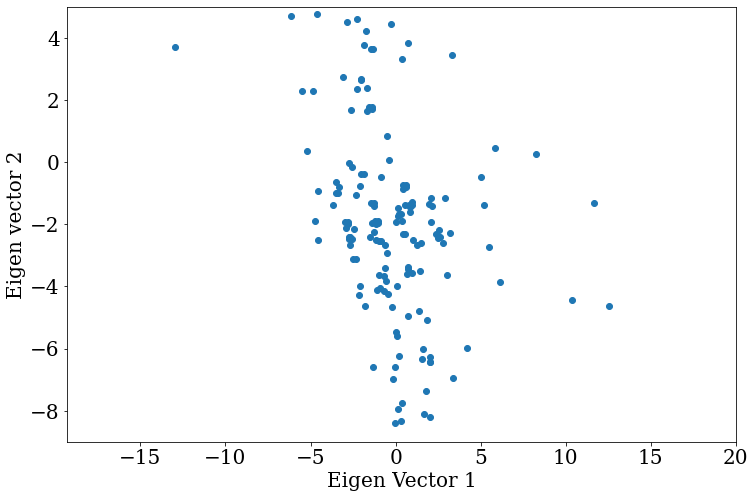

In [20]:
plt.figure(figsize = (12, 8))
plt.scatter(reduced_matrix_cyc[:, 0], reduced_matrix_cyc[:, 1])
plt.xticks(fontsize = "20")
plt.yticks(fontsize = "20")
plt.xlabel('Eigen Vector 1', fontsize = "20")
plt.ylabel('Eigen vector 2', fontsize = "20")
plt.savefig("2D_Projection_matrix_cyclic.pdf", format = 'pdf')
plt.ylim(-9, 5)
plt.show()

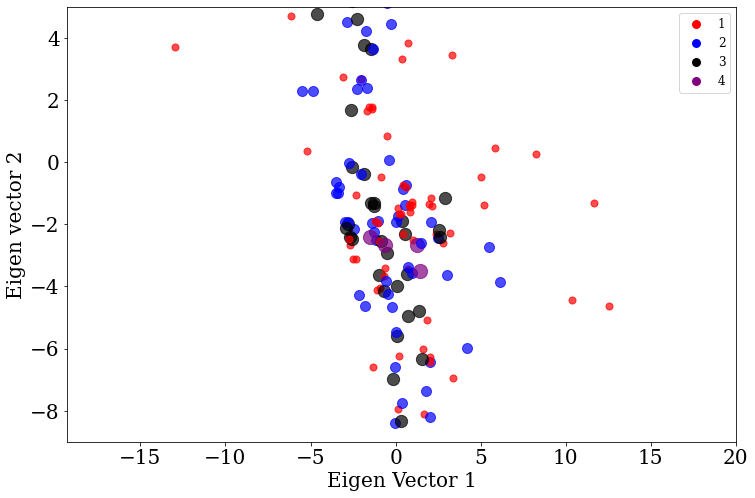

In [111]:
color_map = {1: 'red', 2: 'blue', 3: 'black', 4: 'purple'}

# Your code for creating the plot
plt.figure(figsize=(12, 8))
sizes = np.array(galois_cyc)
x_values_cyc, y_values_cyc = reduced_matrix_cyc[:, 0], reduced_matrix_cyc[:, 1]

for size, x, y in zip(sizes, x_values_cyc, y_values_cyc):
    plt.scatter(x, y, s=size * 50, c=color_map[size], alpha=0.7)

# Create a custom legend
legend_labels = {1: '1', 2: '2', 3: '3', 4: '4'}
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
                  for size, color, label in zip(color_map.keys(), color_map.values(), legend_labels.values())]
plt.legend(handles=legend_handles, fontsize=12)

plt.savefig("galois_orbit_matrix_cyclic.pdf", format='pdf')
plt.xlabel('Eigen Vector 1', fontsize=20)
plt.ylabel('Eigen vector 2', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(-9, 5)

plt.show()  # Display the plot

In [21]:
explained_variance_ratio_cyc = pca_cyc.explained_variance_ratio_
percentage_explained_cyc = explained_variance_ratio_cyc * 100

print("Explained Variance Ratios:", explained_variance_ratio_cyc)
print("Total Explained Variance:", np.sum(explained_variance_ratio_cyc))

Explained Variance Ratios: [0.18713284 0.17020327 0.10649282 0.09954294 0.07182536 0.06018171
 0.05618084 0.04774802 0.04128974 0.03293603 0.02947917 0.0234615
 0.01816109 0.0117944  0.01078935 0.00860286 0.00727563 0.005126
 0.00400678 0.00353238]
Total Explained Variance: 0.9957627235645856


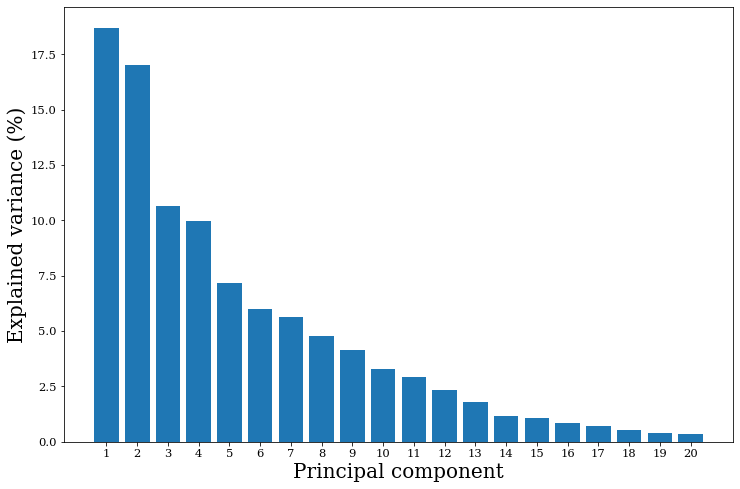

In [22]:
plt.figure(figsize = (12, 8))
plt.bar(range(1, num_components_cyc + 1), percentage_explained_cyc)
plt.xlabel('Principal component', fontsize = "20")
plt.ylabel('Explained variance (%)', fontsize = "20")
plt.yticks(fontsize = "11.5")
plt.xticks(fontsize = "11.5")
plt.xticks(range(1, num_components_cyc + 1))
plt.savefig("histogram_matrix_cyclic.pdf", format = 'pdf')
plt.show()

# K-Means Clustering

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Assuming you have projected your data into 10 dimensions (replace with your data)
projected_data_cyc = projected_datas_cyc  # Replace with your actual data

# Range of cluster numbers to try
cluster_range = range(1, 21)  # You can adjust this range as needed

In [32]:
# Initialize an empty list to store inertia values
inertia_values_cyc = []

# Iterate through the cluster range and fit K-Means for each number of clusters
for num_clusters in cluster_range:
    kmeans_cyc = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_cyc.fit(projected_data_cyc)
    inertia_values_cyc.append(kmeans_cyc.inertia_)

In [30]:
cluster_range, inertia_values_cyc

(range(1, 21),
 [25643.74708452376,
  22156.83784514545,
  18974.488297217784,
  17313.925470761562,
  15465.101877576179,
  14593.148155156907,
  13781.234436516019,
  12931.046561287183,
  12286.458195673888,
  11793.709186113612,
  11378.030872266754,
  10367.054957550865,
  10309.744636462357,
  9629.9911130782,
  9392.875588245923,
  9088.949773514718,
  8953.242513489386,
  8635.282601665169,
  8418.18013060983,
  8038.557836708774])

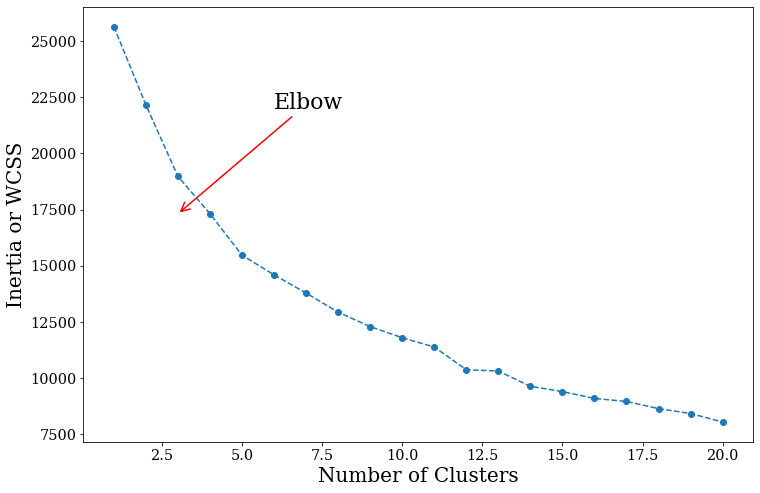

In [31]:
# Plot the inertia values against the number of clusters

plt.figure(figsize=(12, 8))
plt.plot(cluster_range, inertia_values_cyc, marker='o', linestyle='--')
#plt.title('Elbow Method for Optimal Cluster Number')
plt.xlabel('Number of Clusters', fontsize = "20")
plt.ylabel('Inertia or WCSS', fontsize = "20")
plt.yticks(fontsize = "14.5")
plt.xticks(fontsize = "14.5")
plt.annotate('Elbow', xy=(3, 17313), xytext=(6, 22000),
             arrowprops=dict(arrowstyle='->', lw=1.5, color='r'))
plt.savefig("clustering_matrix_cyclic.pdf")
plt.show()